<a href="https://colab.research.google.com/github/Prashanna-Raj-Pandit/InsuranceModel-Insurance-Premium-Prediction/blob/main/01_Neural_NET_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)

2.18.0


# Creating data to view and fit

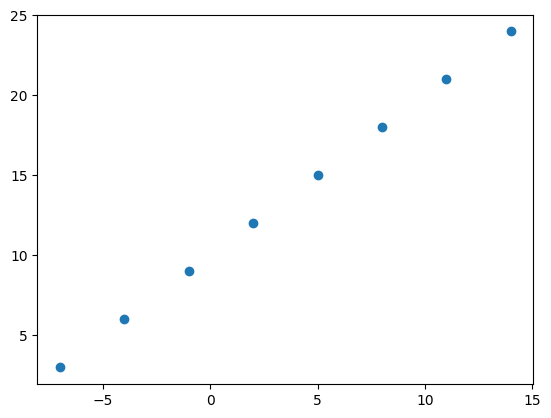

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# create features i.e input features
X=np.array([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0]) # independent variable x-axis. its called the fratures variable
X = np.array(X).reshape(-1, 1)

# create labels
y=np.array([3.0,6.0,9.0,12.0,15.0,18.0,21.0,24.0]) # dependent variable y axis or its the outcome variable

# visualize it
plt.scatter(X,y)

In [3]:
y==X+10


array([[ True, False, False, False, False, False, False, False],
       [False,  True, False, False, False, False, False, False],
       [False, False,  True, False, False, False, False, False],
       [False, False, False,  True, False, False, False, False],
       [False, False, False, False,  True, False, False, False],
       [False, False, False, False, False,  True, False, False],
       [False, False, False, False, False, False,  True, False],
       [False, False, False, False, False, False, False,  True]])

# input and output shape

In [4]:
input_shape=X.shape
output_shape=y.shape
input_shape,output_shape # here the shape is 8. This array is 1-dimensional (1D) with a shape of (8,), meaning it contains 8 elements in a single row.



((8, 1), (8,))

In [5]:
input_shape=X[0].shape
output_shape=y[0].shape
input_shape,output_shape

((1,), ())

In [6]:
X[0].ndim # so this is basically scalar having 0 dimention thats why it has no shape

1

In [7]:
X[0],y[0] # we are going to use one X value to predict one y value

(array([-7.]), np.float64(3.0))

#converting numpy into tensor

In [8]:
X=tf.cast(tf.constant(X),dtype=tf.float32)
y=tf.cast(tf.constant(y),dtype=tf.float32)
X,y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [9]:
input_shape=X[0].shape
output_shape=y[0].shape
input_shape,output_shape

(TensorShape([1]), TensorShape([]))

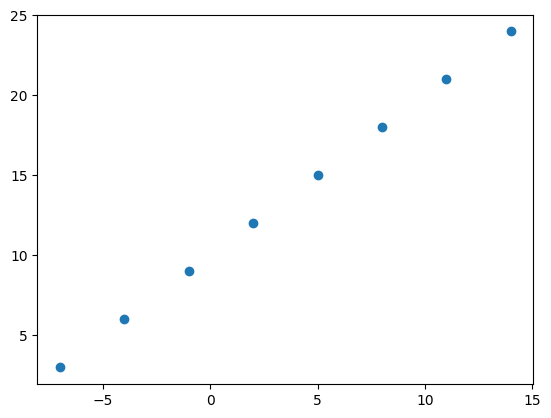

In [10]:
plt.scatter(X,y)

#steps in modeling with tensorflow
1. Creating a model - define the input and output layers, as well as the hidden layers of a deep learning model.
2. Compiling a model - define the loss funtion (in other words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patterns its learning) and evaluation metrics (what we can use to interpret the performance of our model).
3. Fitting a model - letting the model try to find patterns between X & y (features and labels).

Sequential groups a linear stack of layers into a Model.

Examples:

model = keras.Sequential()

model.add(keras.Input(shape=(16,)))

model.add(keras.layers.Dense(8))

:::ValueError::: Input 0 of layer "dense_3" is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (None,)

The error indicates that the input data to the Dense layer does not meet the layer's requirement for a minimum of two dimensions (2D). A Dense layer expects inputs in the shape (batch_size, num_features), where num_features is the number of input features per sample.

Cause of the Issue:
>The input data X is likely a 1D array with a shape like (None,), which corresponds to a single feature without the batch dimension explicitly specified.

Solution:
>Need to reshape X into a 2D array before passing it to the model. You can do this using numpy or other methods, depending on how X is structured.


Ensure X is a 2D array:
>X = np.array(X).reshape(-1, 1)  # Reshape to (batch_size, num_features)

Fit the model:
>model.fit(X, y, epochs=5)

Explanation:
>np.array(X).reshape(-1, 1) ensures X has two dimensions, where:
-1 lets NumPy automatically infer the number of rows (batch size).
1 specifies the number of features per sample.

In [11]:
# set random seed
tf.random.set_seed(42)

# create a model using sequential API
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#compile the model
model.compile(loss=tf.keras.losses.mae,  #loss = keras.losses.mean_absolute_error(y_true, y_pred)
              optimizer=tf.keras.optimizers.SGD(), # Stocastic gradient Descent
              metrics=["mae"])

# fit the model

model.fit(X,y,epochs=5)

# Fit the model
# model.fit(tf.expand_dims(X, axis=-1), y, epochs=5) # <- updated line
# The code adds an extra dimension to X on the last axis, turning it ndim=1 to ndim=2 (what the model requires).

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 10.9431 - mae: 10.9431
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 10.8106 - mae: 10.8106
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 10.6781 - mae: 10.6781
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 10.5456 - mae: 10.5456
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 10.4131 - mae: 10.4131


In [12]:
X,y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

ValueError: Unrecognized data type: x=[17.0] (of type <class 'list'>)

The error occurs because model.predict expects the input data to be in a specific format, typically a NumPy array or a tensor with at least two dimensions (as required by the Dense layer). However, [17.0] is a Python list, which is not directly compatible.

Fix:
>Need to convert the input [17.0] into a 2D NumPy array or tensor with the proper shape. Here's how to fix it:

In [13]:
# make prediction by using our model
# model.predict([17.0])
# Convert the input to a 2D array
input_data = np.array([17.0]).reshape(-1, 1)

# Make the prediction
prediction = model.predict(input_data)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


array([[15.444465]], dtype=float32)

In [14]:
X.ndim

2

Explanation of .reshape(-1, 1)
-1: This tells NumPy to infer the number of rows automatically based on the total number of elements in the array. In this case, since there are 8 elements, it infers 8 rows.
1: This explicitly sets the number of columns to 1, making it a 2D array with a single feature.

# Improving our model


In [15]:
# creating
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#compiling
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

#fit
model.fit(X,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step - loss: 20.1408 - mae: 20.1408
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 19.8595 - mae: 19.8595
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 19.5783 - mae: 19.5783
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 19.2970 - mae: 19.2970
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 19.0158 - mae: 19.0158
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 18.7345 - mae: 18.7345
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 18.4533 - mae: 18.4533
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 18.1720 - mae: 18.1720
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 17.8908 - mae: 17.8908
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 17.6095 - mae: 17.6095
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 17.3283 - mae: 17.3283
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 17.0470 - mae: 17.0470
Epoch 13/100
1/1 ━━━━━

In [16]:
input_data = np.array([17.0]).reshape(-1, 1)
model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[29.322943]], dtype=float32)

Changing optimizer and adding learning rate

In [17]:

model=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#compiling
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mae"])

#fit
model.fit(X,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step - loss: 9.3742 - mae: 9.3742
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.9242 - mae: 8.9242
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8.4742 - mae: 8.4742
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 8.0243 - mae: 8.0243
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 7.5743 - mae: 7.5743
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.1250 - mae: 7.1250
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7.0513 - mae: 7.0513
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 6.9784 - mae: 6.9784
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.0972 - mae: 7.0972
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.1586 - mae: 7.1586
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7.1627 - mae: 7.1627
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.1206 - mae: 7.1206
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/st

In [18]:
X,y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [19]:
model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[27.285563]], dtype=float32)

Adding more hidden layer

In [20]:
# creating
model=tf.keras.Sequential([
    tf.keras.layers.Dense(8,activation="relu")
])

#compiling
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mae"])

#fit
model.fit(X,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step - loss: 12.1821 - mae: 12.1821
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.7799 - mae: 11.7799
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 11.4187 - mae: 11.4187
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.1121 - mae: 11.1121
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.8740 - mae: 10.8740
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 10.7021 - mae: 10.7021
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 10.5357 - mae: 10.5357
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 10.3642 - mae: 10.3642
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.2158 - mae: 10.2158
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 10.0746 - mae: 10.0746
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 9.9644 - mae: 9.9644
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 9.8724 - mae: 9.8724
Epoch 13/100
1/1 ━━━━━━━━━━━

In [21]:
input_data = np.array([17.0]).reshape(-1, 1)
model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[12.204144 ,  8.607263 ,  0.       ,  6.2022896,  0.       ,
         3.5793664, 27.031479 , 17.304201 ]], dtype=float32)

#Evaluating a model
build->evaluate->tweak->evaluate->tweak->evaluate->tweak......

when it comes to evaluation we shoul memorize
> visualize, visualize, visualize


*   data
*   model
*   training
*   prediction




In [22]:
# Make a bigger dataset

X=tf.range(-100,100,4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [23]:
# make labels for the dataset
y=X+10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

# Spliting data into train and test sample

In [24]:
x_train=X[:40]
x_test=X[40:]
y_train=y[:40]
y_test=y[40:]
x_train,x_test,y_train,y_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([60, 64, 68, 72, 76, 80, 84, 88, 92, 96], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

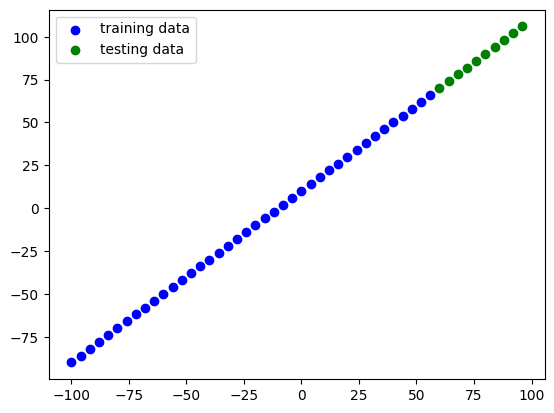

In [25]:
plt.scatter(x_train,y_train,c="b",label="training data")
plt.scatter(x_test,y_test,c="g",label="testing data")
plt.legend()

>**NOTE** The Dense layer in this model is configured with input_shape=[1], meaning it expects input data with 1 features per sample.

In [26]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(10,input_shape=[1],name="input_layer"),
    tf.keras.layers.Dense(1,name="output_layer")
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mae"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (Dense)                  │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

The parameters here represent the weights and bias.

number of Params=input*number of neurons (represent weight. one per neuron)+ number of neurons(bias)

In [28]:
# fit our model
model.fit(tf.reshape(x_train,shape=(-1,1)),y_train,epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - loss: 68.1580 - mae: 68.1580
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14.9616 - mae: 14.9616
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 28.5065 - mae: 28.5065
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 17.8210 - mae: 17.8210
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.6858 - mae: 11.6858
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 18.0062 - mae: 18.0062
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 10.2692 - mae: 10.2692
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 8.8730 - mae: 8.8730
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 11.6816 - mae: 11.6816
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.2732 - mae: 8.2732
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.9246 - mae: 4.9246
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.0358 - mae: 7.0358
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

#plot Model

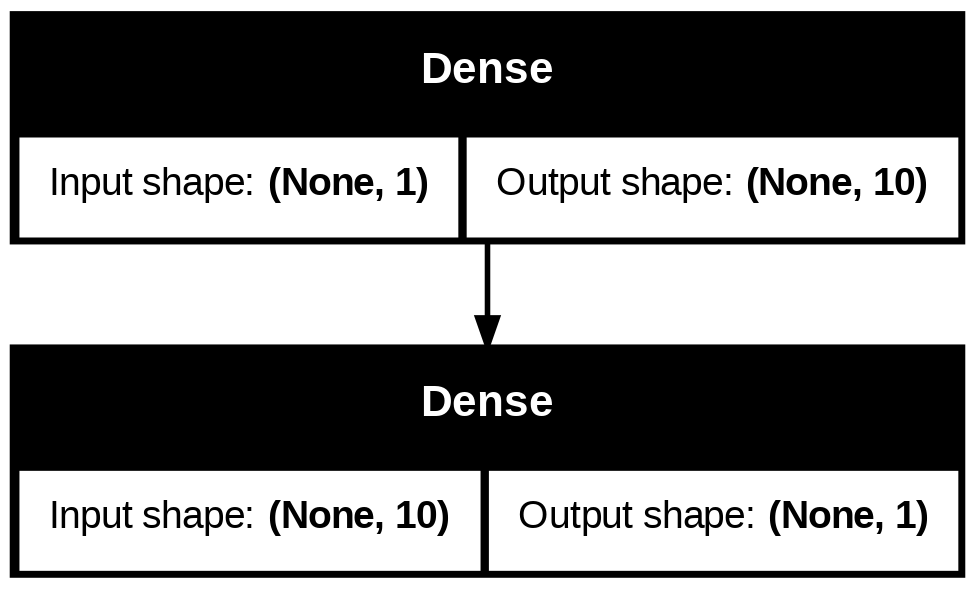

In [29]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True)

#Visualizing our model predictions
y_test vs y_pred or ground truth vs predicted

In [30]:
# Make some predictions
y_pred=model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


array([[ 69.12309 ],
       [ 73.05615 ],
       [ 76.98924 ],
       [ 80.92228 ],
       [ 84.85537 ],
       [ 88.78844 ],
       [ 92.72148 ],
       [ 96.654564],
       [100.58763 ],
       [104.5207  ]], dtype=float32)

In [31]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

#plotting function

In [32]:
def plot_prediction(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=y_pred):
  plt.figsize=(10,7)
  plt.scatter(train_data,train_labels,c="b",label='training data')
  plt.scatter(test_data,test_labels,c="g",label="testing data")
  plt.scatter(test_data,predictions,c="r",label="predictions")
  plt.legend()

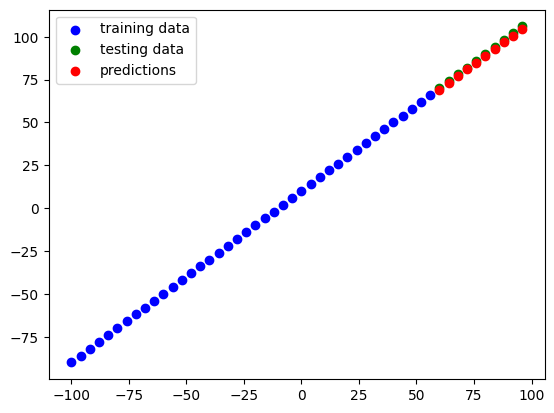

In [33]:
plot_prediction(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=y_pred)

#Evaluating our model's prediction with regression evaluation metrics
Mean Square Error and Mean Absoulte Error

In [34]:
model.evaluate(x_test,y_test) #Returns the loss value & metrics values for the model in test mode

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 1.1781 - mae: 1.1781


[1.178105115890503, 1.178105115890503]

In [35]:
tf.keras.metrics.mae(y_test,y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.87690735, 0.94384766, 1.0107574 , 1.0777206 , 1.1446304 ,
       1.2115631 , 1.2785187 , 1.3454361 , 1.4123688 , 1.4793015 ],
      dtype=float32)>

#Shape Mismatch Between y_test and y_pred:

The y_test and y_pred tensors must have the same shape. If they don't, TensorFlow will attempt to broadcast them, leading to incorrect results.
Ensure both tensors are 1D or have compatible shapes for element-wise subtraction.


In [36]:
tf.keras.metrics.mse(y_test,y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.7689665, 0.8908484, 1.0216306, 1.1614817, 1.3101789, 1.4678851,
       1.63461  , 1.8101983, 1.9947855, 2.1883328], dtype=float32)>

In [37]:
tf.keras.metrics.huber(y_test,y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.38448325, 0.4454242 , 0.51075745, 0.57772064, 0.64463043,
       0.7115631 , 0.7785187 , 0.8454361 , 0.9123688 , 0.97930145],
      dtype=float32)>

In [38]:
y_pred,y_pred.shape # lets change its shape.

(array([[ 69.12309 ],
        [ 73.05615 ],
        [ 76.98924 ],
        [ 80.92228 ],
        [ 84.85537 ],
        [ 88.78844 ],
        [ 92.72148 ],
        [ 96.654564],
        [100.58763 ],
        [104.5207  ]], dtype=float32),
 (10, 1))

In [39]:
y_test,y_pred

(<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>,
 array([[ 69.12309 ],
        [ 73.05615 ],
        [ 76.98924 ],
        [ 80.92228 ],
        [ 84.85537 ],
        [ 88.78844 ],
        [ 92.72148 ],
        [ 96.654564],
        [100.58763 ],
        [104.5207  ]], dtype=float32))

In [40]:
y_test,tf.squeeze(y_pred)


(<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 69.12309 ,  73.05615 ,  76.98924 ,  80.92228 ,  84.85537 ,
         88.78844 ,  92.72148 ,  96.654564, 100.58763 , 104.5207  ],
       dtype=float32)>)

In [41]:
mae_1=tf.metrics.mae(y_test,tf.squeeze(y_pred))
mae_1

<tf.Tensor: shape=(), dtype=float32, numpy=1.178105115890503>

In [42]:
mse_1=tf.metrics.mse(y_test,tf.squeeze(y_pred))
mse_1

<tf.Tensor: shape=(), dtype=float32, numpy=1.4248918294906616>

# Running experiment to improve our model




1.   Get More data
2.   Making model larger
3.   Train for longer

lets make 3 model with different NN and epochs


In [43]:
# model 1. same as above

In [44]:
# model 2
tf.random.set_seed(42)
model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(10,input_shape=[1]),
    tf.keras.layers.Dense(1)
])
model_2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mae"])
model_2.fit(x_train,y_train,epochs=100)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - loss: 33.2828 - mae: 33.2828
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 12.4541 - mae: 12.4541 
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.9143 - mae: 8.9143
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 7.9123 - mae: 7.9123
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 6.7285 - mae: 6.7285
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.1481 - mae: 8.1481
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.0817 - mae: 7.0817
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.8754 - mae: 5.8754
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.8102 - mae: 4.8102
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.2965 - mae: 4.2965
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.6956 - mae: 2.6956
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.7001 - mae: 2.7001
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


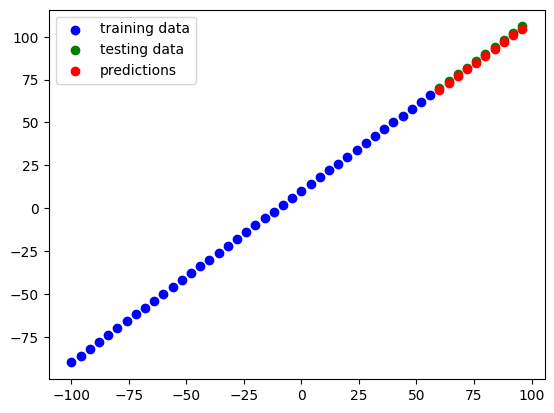

In [45]:
y_pred=model_2.predict(x_test)
plot_prediction(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=y_pred)

In [46]:
#  model_3
tf.random.set_seed(42)
model_3=tf.keras.Sequential([
    tf.keras.layers.Dense(10,input_shape=[1]),
    tf.keras.layers.Dense(1)
])
model_3.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mae"])
model_3.fit(x_train,y_train,epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 20.7224 - mae: 20.7224
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 18.4171 - mae: 18.4171
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.3212 - mae: 8.3212
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.5530 - mae: 9.5530
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.3977 - mae: 8.3977
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.8482 - mae: 7.8482
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7.3713 - mae: 7.3713
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.5798 - mae: 6.5798
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.7207 - mae: 6.7207
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 6.4647 - mae: 6.4647
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 4.0486 - mae: 4.0486
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.6278 - mae: 3.6278 
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


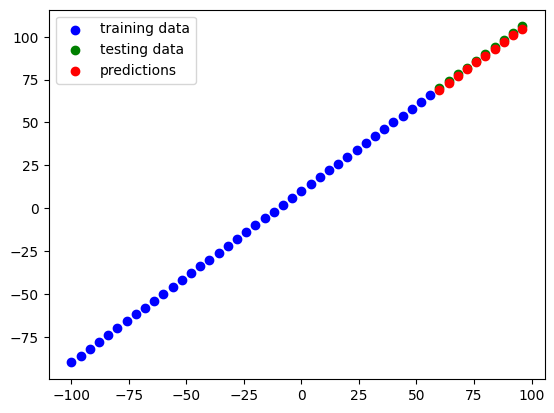

In [47]:
y_pred=model_3.predict(x_test)
plot_prediction(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=y_pred)

In [48]:
mae_3=tf.metrics.mae(y_test,tf.squeeze(y_pred))
mse_3=tf.metrics.mse(y_test,tf.squeeze(y_pred))
mae_3,mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=1.0372231006622314>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1.09659743309021>)

# compare model using pandas dataframe

In [49]:
import pandas as pd
model_results=[["model_1",mae_1.numpy(),mse_1.numpy()],
               ["model_3",mae_3.numpy(),mse_3.numpy()]]
results=pd.DataFrame(model_results,columns=["model","mae","mse"])
results

,model,mae,mse
0,model_1,1.178105,1.424892
1,model_3,1.037223,1.096597


#saving our models


1.   saved model format
2.   HDF5 format



In [50]:
model_2.save("path_to_save_model.h5")


In [51]:
#loading model
loaded_h5_model=tf.keras.models.load_model("path_to_save_model.h5")
loaded_h5_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [52]:
model_2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

#Downloading files from google colab.


1.   click on right side to download
2.   import google files code to download



In [53]:
from google.colab import files
files.download("path_to_save_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# A larger example
 larger dataset

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [55]:
# read in the insurane dataset
insurance=pd.read_csv("https://gist.githubusercontent.com/meperezcuello/82a9f1c1c473d6585e750ad2e3c05a41/raw/d42d226d0dd64e7f5395a0eec1b9190a10edbc03/Medical_Cost.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [56]:
insurance['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [57]:
insurance['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [58]:
insurance['bmi'].dtype

dtype('float64')

#one hot encoding our dataframe

In [59]:
insurance_one_hot=pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [60]:
insurance_one_hot["sex_female"].dtype

dtype('bool')

In [61]:
insurance_one_hot["age"]

,age
0,19
1,18
2,28
3,33
4,32
...,...
1333,50
1334,18
1335,18
1336,21


In [62]:
# split dataset
X=insurance_one_hot.drop("charges",axis=1)
y=insurance_one_hot["charges"]


In [63]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [64]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


create training and testing sets by sklern

In [65]:
from sklearn.model_selection import train_test_split #Split arrays or matrices into random train and test subsets.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [66]:
import tensorflow as tf
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
    ])
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=["mae"])

insurance_model.fit(X_train,y_train,epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 10342.2871 - mae: 10342.2871
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7710.2324 - mae: 7710.2324
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7660.1182 - mae: 7660.1182
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7728.5527 - mae: 7728.5527
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7377.5762 - mae: 7377.5762
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7672.1704 - mae: 7672.1704
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7575.0312 - mae: 7575.0312
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7818.3032 - mae: 7818.3032
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7649.2515 - mae: 7649.2515
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7601.7822 - mae: 7601.7822
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7636.1206 - mae: 7636.1206
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

In [67]:
y_pred=insurance_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Lets evaluate our model

In [68]:
insurance_model.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6337.9985 - mae: 6337.9985


[6199.62158203125, 6199.62158203125]

In [69]:
y_train.mean(
)

np.float64(13346.089736364485)

#improving our model

In [70]:
tf.random.set_seed(42)

insurance_model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                          metrics=["mae"])
history=insurance_model_2.fit(X_train,y_train,epochs=200,verbose=1)


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 12566.4951 - mae: 12566.4951
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7513.7935 - mae: 7513.7935
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7233.6802 - mae: 7233.6802
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7019.7305 - mae: 7019.7305
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6749.7329 - mae: 6749.7329
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6415.1553 - mae: 6415.1553
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6256.5366 - mae: 6256.5366
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6123.6523 - mae: 6123.6523
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5986.9155 - mae: 5986.9155
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5802.1846 - mae: 5802.1846
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5560.4678 - mae: 5560.4678
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

In [71]:
insurance_model_2.evaluate(X_test,y_test
                           )

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3225.7571 - mae: 3225.7571


[3161.88525390625, 3161.88525390625]

#Losss curve or training curve

Text(0.5, 0, 'epochs')

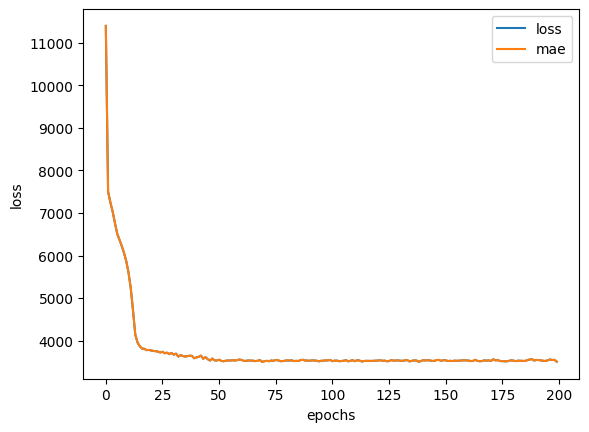

In [72]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

> So How long do you train for? for this, tensorflow has a solution. i.e. EarlyStoppingCallback which is a tensorflow component which can be add in our model to stop training when our model stop improving after certain metric.

# Preprocessing data. Normalization and standardisation
in terms of scaling values NN prefers normalization
To prepare out data. we can burrow a few classes from sikit-learn


<Axes: ylabel='Frequency'>

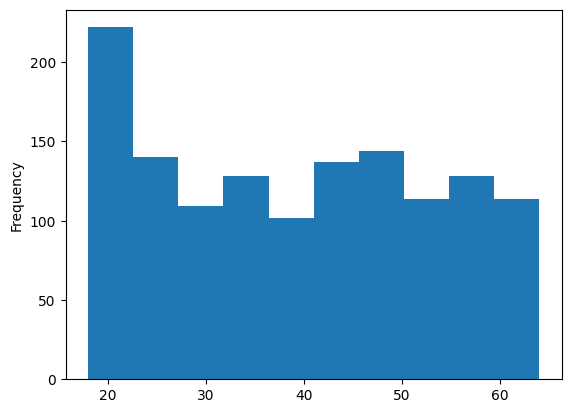

In [73]:
X["age"].plot(kind="hist")

<Axes: ylabel='Frequency'>

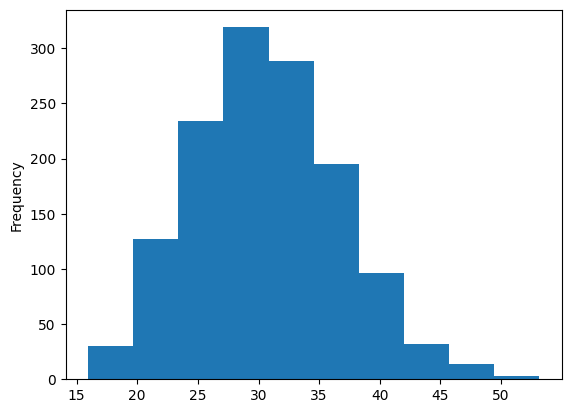

In [74]:
X["bmi"].plot(kind="hist")

#Correct Syntax for ColumnTransformer
When creating a ColumnTransformer, its components should be passed as a list of tuples inside the constructor. Each tuple contains:

A name for the transformer (e.g., "scaler" or "onehot").

The transformer object (e.g., MinMaxScaler() or OneHotEncoder()).

The column names to which the transformer should be applied.

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Creating a column transformer
ct = ColumnTransformer(
    transformers=[
        ("scaler", MinMaxScaler(), ["age", "bmi", "children"]),  # Scale these columns
        ("onehot", OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])  # One-hot encode these columns
    ]
)

# Create X and y
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the column transformer on training data
ct.fit(X_train)

# Transform the training and test data
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)


In [76]:
X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [77]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [78]:
X_train_normal

array([[0.60869565, 0.10734463, 0.4       , ..., 1.        , 0.        ,
        0.        ],
       [0.63043478, 0.22491256, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.73913043, 0.23944041, 0.        , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.86956522, 0.24791499, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.41304348, 0.85122411, 0.4       , ..., 0.        , 0.        ,
        1.        ],
       [0.80434783, 0.37503363, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [79]:
X_train.shape,X_train_normal.shape # columns are added by one hot encoder

((1070, 6), (1070, 11))

Our data is normalized and one hot encoded. lets build our neural network based on this data

In [80]:
tf.random.set_seed(42)
insurance_model_normalized=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model_normalized.compile(loss=tf.keras.losses.mae,
                                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                                   metrics=["mae"])
history=insurance_model_normalized.fit(X_train_normal,y_train,epochs=100,verbose=1)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 13261.4639 - mae: 13261.4639
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12173.8301 - mae: 12173.8301
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8465.7715 - mae: 8465.7715
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7607.0957 - mae: 7607.0957
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7151.2700 - mae: 7151.2700
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6564.7319 - mae: 6564.7319
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5706.2915 - mae: 5706.2915
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4527.4795 - mae: 4527.4795
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3728.0588 - mae: 3728.0588
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3638.1663 - mae: 3638.1663
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3625.4922 - mae: 3625.4922
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

Text(0.5, 0, 'epochs')

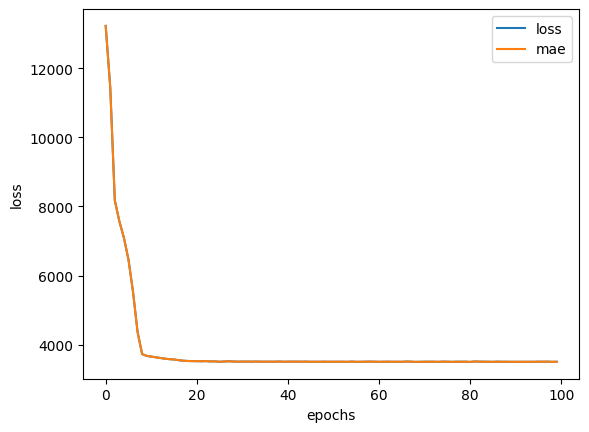

In [81]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

In [82]:
insurance_model_normalized.evaluate(X_test_normal,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3213.6387 - mae: 3213.6387


[3161.993896484375, 3161.993896484375]

In [83]:
X_test_normal[0]

array([0.58695652, 0.24791499, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 0.        ,
       0.        ])

In [84]:
single_sample = X_test_normal[0].reshape(1, -1)  # -1 infers the size (11)
prediction = insurance_model_normalized.predict(single_sample)
print("Prediction for the first test sample:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Prediction for the first test sample: 9166.436


# Saving and loading model

In [85]:
import pickle
with open("insurance_model.pkl","wb") as f:
  pickle.dump(insurance_model_normalized,f)

In [86]:
with open("insurance_model.pkl","rb") as f:
  loaded_model=pickle.load(f)

In [87]:
loaded_model_prediction=loaded_model.predict(single_sample)
loaded_model_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


array([[9166.436]], dtype=float32)

In [88]:
insurance_model_normalized.predict(single_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[9166.436]], dtype=float32)

In [89]:
insurance_model_2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 100)                 │           1,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,665 (26.04 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,444 (17.36 KB)

In [90]:
insurance_model_normalized.summary(

)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 100)                 │           1,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,665 (26.04 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,444 (17.36 KB)

In [91]:
import pandas as pd
# age	sex	bmi	children	smoker	region
age=int(input("enter age: "))
sex=input("enter sex: ")
bmi=float(input("enter bmi: "))
children=int(input("enter children: "))
smoker=input("enter smoker: ")
region=input("enter region: ")
input_df=pd.DataFrame([[age,sex,bmi,children,smoker,region]],columns=["age","sex","bmi","children","smoker","region"])
input_df

enter age: 23
enter sex: male
enter bmi: 33
enter children: 3
enter smoker: no
enter region: southwest


,age,sex,bmi,children,smoker,region
0,23,male,33.0,3,no,southwest


In [92]:
X_test.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object


In [93]:
input_df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object


In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Creating a column transformer
ct = ColumnTransformer(
    transformers=[
        ("scaler", MinMaxScaler(), ["age", "bmi", "children"]),  # Scale these columns
        ("onehot", OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])  # One-hot encode these columns
    ]
)
ct.fit(X_train)
# Transform the user input data
user_data_norm = ct.transform(input_df)


In [99]:
user_data_norm

array([[0.10869565, 0.45843422, 0.6       , 0.        , 1.        ,
        1.        , 0.        , 0.        , 0.        , 0.        ,
        1.        ]])

In [100]:
insurance_premium=insurance_model_normalized.predict(user_data_norm)
float(insurance_premium[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


3160.78369140625

In [102]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import pickle

# Load data
insurance = pd.read_csv("https://gist.githubusercontent.com/meperezcuello/82a9f1c1c473d6585e750ad2e3c05a41/raw/d42d226d0dd64e7f5395a0eec1b9190a10edbc03/Medical_Cost.csv")
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and fit ColumnTransformer
ct = ColumnTransformer(
    transformers=[
        ("scaler", MinMaxScaler(), ["age", "bmi", "children"]),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
    ]
)
ct.fit(X_train)

# Save the fitted ColumnTransformer
with open("column_transformer.pkl", "wb") as f:
    pickle.dump(ct, f)

# (Optional) Train and save the model if not already done
tf.random.set_seed(42)
insurance_model_normalized = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model_normalized.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)
insurance_model_normalized.fit(ct.transform(X_train), y_train, epochs=100, verbose=1)
insurance_model_normalized.save("insurance_model.h5")  # Use HDF5 for reliability

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 13253.4395 - mae: 13253.4395
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12076.5488 - mae: 12076.5488
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8387.5645 - mae: 8387.5645
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7591.1729 - mae: 7591.1729
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7133.8657 - mae: 7133.8657
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6539.3882 - mae: 6539.3882
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5664.7397 - mae: 5664.7397
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4478.9248 - mae: 4478.9248
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3718.7837 - mae: 3718.7837
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3640.1445 - mae: 3640.1445
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3623.7715 - mae: 3623.7715
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [104]:
insurance_model_1=tf.keras.models.load_model("insurance_model.h5")
insurance_model_1.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 100)                 │           1,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,223 (8.69 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [105]:
insurance_model_1.predict(user_data_norm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


array([[3155.3833]], dtype=float32)